### Import Necessary Libraries

In [1]:
import numpy as np 
import pandas as pd
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
from scipy.stats import pointbiserialr
import matplotlib.pyplot as plt 
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import RidgeClassifier, LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import BernoulliNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, recall_score,
    precision_score, f1_score, cohen_kappa_score,
    matthews_corrcoef
)

import kagglehub
import shutil
import os
from ucimlrepo import fetch_ucirepo

g:\anaconda3\envs\ds\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Data Load

In [2]:
# Kaggle
dataset_dir = "data\\"
if len(os.listdir(dataset_dir)) == 0:
    path = kagglehub.dataset_download("redwankarimsony/heart-disease-data")
    shutil.move(path, dataset_dir)

print("dataset downloaded")

dataset downloaded


In [3]:
# uncomment if use data from kaggle
data_path = "data\\6\\heart_disease_uci.csv"
df = pd.read_csv(data_path, index_col=0)

### Initial Data Examination

In [4]:
df.head()

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
id,,,,,,,,,,,,,,,
1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [5]:
df.tail()

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
id,,,,,,,,,,,,,,,
916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0
920,62,Male,VA Long Beach,atypical angina,120.0,254.0,False,lv hypertrophy,93.0,True,0.0,NaN,NaN,NaN,1


In [6]:
df.sample()

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
id,,,,,,,,,,,,,,,
547,54,Male,Hungary,asymptomatic,130.0,603.0,True,normal,125.0,True,1.0,flat,NaN,NaN,1


In [7]:
df.shape

(920, 15)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 920 entries, 1 to 920
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       920 non-null    int64  
 1   sex       920 non-null    object 
 2   dataset   920 non-null    object 
 3   cp        920 non-null    object 
 4   trestbps  861 non-null    float64
 5   chol      890 non-null    float64
 6   fbs       830 non-null    object 
 7   restecg   918 non-null    object 
 8   thalch    865 non-null    float64
 9   exang     865 non-null    object 
 10  oldpeak   858 non-null    float64
 11  slope     611 non-null    object 
 12  ca        309 non-null    float64
 13  thal      434 non-null    object 
 14  num       920 non-null    int64  
dtypes: float64(5), int64(2), object(8)
memory usage: 115.0+ KB


### Check Duplicate Rows and Remove Duplicates

In [9]:
df.duplicated().sum()

np.int64(2)

In [10]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

### Identify Missing Value and Handling

In [11]:
df.isnull().sum()

age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         29
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       307
ca          609
thal        484
num           0
dtype: int64

In [12]:
y = pd.DataFrame(df['num'].values)
X = df.drop(columns=['num', 'dataset'])
numerical_feature = X.select_dtypes(include=["int64", "float64"]).columns.to_list()
categorical_feature = X.select_dtypes(exclude=["int64", "float64"]).columns.to_list()
numerical_feature.remove('ca')
categorical_feature.append('ca')
X[categorical_feature] = X[categorical_feature].astype(str)

In [13]:
def transform_to_biner(x):
    if x != 0:
        x = 1
    return x

y = y.squeeze()
y = y.apply(transform_to_biner)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
preprocessor_imputation = ColumnTransformer(
    transformers=[
        ("numerical", Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),
        ]), numerical_feature),
        ("categorical", Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
        ]), categorical_feature)
    ]
)

preprocessor_imputation.set_output(transform="pandas")
X_train = preprocessor_imputation.fit_transform(X_train)
X_test = preprocessor_imputation.transform(X_test)  

In [16]:
X_train.sample()

,numerical__age,numerical__trestbps,numerical__chol,numerical__thalch,numerical__oldpeak,categorical__sex,categorical__cp,categorical__fbs,categorical__restecg,categorical__exang,categorical__slope,categorical__thal,categorical__ca
id,,,,,,,,,,,,,
523,57.0,140.0,265.0,145.0,1.0,Male,atypical angina,False,st-t abnormality,True,flat,nan,nan


### Outliers Check (numerical)

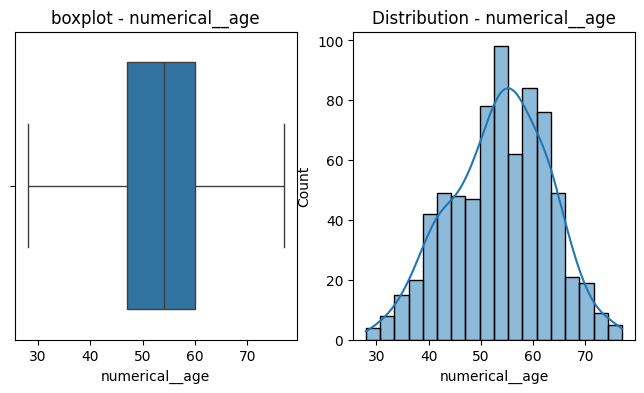

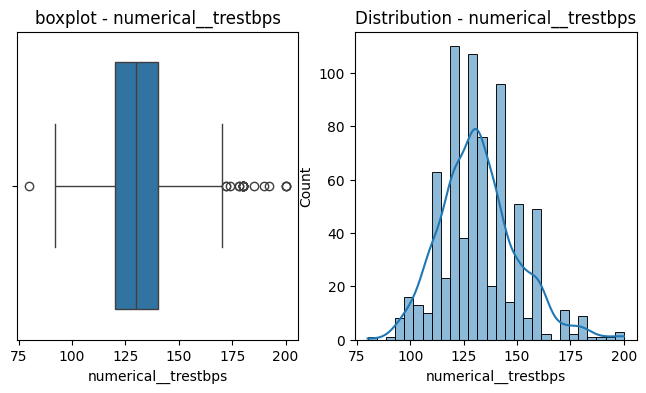

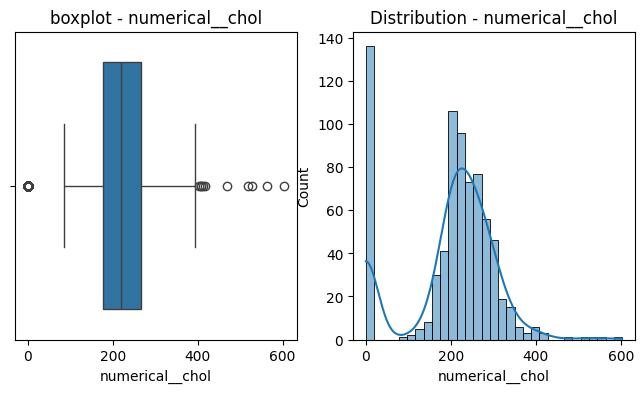

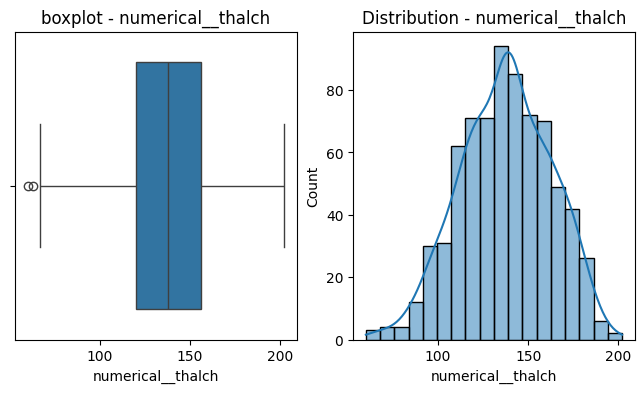

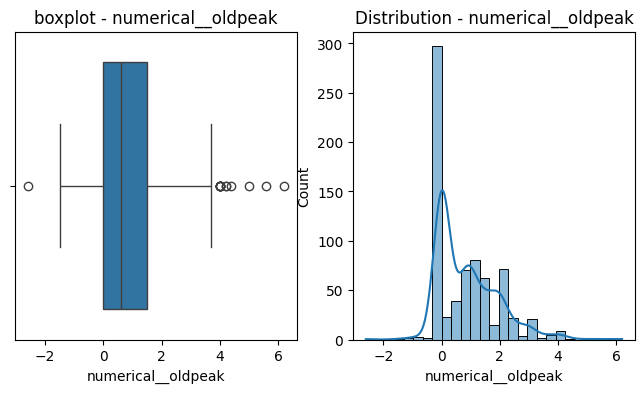

In [17]:
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_cols:
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))

    sns.boxplot(x=X_train[col], ax=axes[0])
    axes[0].set_title(f'boxplot - {col}')

    sns.histplot(x=X_train[col], ax=axes[1], kde=True)
    axes[1].set_title(f'Distribution - {col}')

    plt.show()

<ul>
    <li>Normal -> Z-Score
    <li>Skewed -> IQR
    <li>Mixed/Unknown -> IQR (safer default)
</ul>

<p>Berdasarkan hasil plot histogram kolom age, trestbps, thalch menunjukan distribusi normal sehingga menggunakan Z-Score dalam melakukan <i>outliers check</i>, sedangkan kolom chol, oldpeak, dan menunjukan distibusi cenderung skewed sehingga menggunakan IQR.</p>

In [19]:
skewed_dist = ['numerical__oldpeak', 'numerical__chol']
def iqr(x):
    Q1 = x.quantile(0.25)
    Q3 = x.quantile(0.75)
    IQR = Q3-Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = ((x < lower_bound) | (x > upper_bound)).sum()
    print(f'{col}: {outlier_count}')
    return lower_bound, upper_bound

for col in skewed_dist:
    _, _ = iqr(X_train[col])

numerical__oldpeak: 14
numerical__chol: 146


In [20]:
normal_dist = ['numerical__thalch', 'numerical__trestbps', 'numerical__age']
for col in normal_dist:
    z_scores = np.abs(stats.zscore(X_train[col]))
    outlier_count = (z_scores > 3).sum()
    total = len(X_train[col])
    percentage = (outlier_count / total) * 100
    print(f"{col}: {outlier_count} outliers out of {total} rows ({percentage:.2f}%)")

numerical__thalch: 1 outliers out of 734 rows (0.14%)
numerical__trestbps: 5 outliers out of 734 rows (0.68%)
numerical__age: 0 outliers out of 734 rows (0.00%)


<p>Berdasarkan hasil deteksi outlier menggunakan IQR dan Z-Score, didapatkan hasil jumlah outliers masing masing kolom:</p>
<ul>
    <li> oldpeak = 14
    <li> chol = 146
    <li> thalch = 1
    <li> trestbps = 5
    <li> age = 0
</ul>

<p>Untuk menangani outliers diputuskan menggunakan Capping</p>

### Outliers Handling (numerical)

In [21]:
def zscore_cap(x):
    mean = x.mean()
    std  = x.std()
    
    lower_bound = mean - 3 * std
    upper_bound = mean + 3 * std
    
    outlier_count = (np.abs(stats.zscore(x)) > 3).sum()
    print(f"   outliers found: {outlier_count}")
    
    return lower_bound, upper_bound

print("=== Capping Skewed Columns (IQR) ===")
skewed_bounds = {}
for col in skewed_dist:
    print(f"{col}:")
    lower, upper = iqr(X_train[col])
    skewed_bounds[col] = {'lower': lower, 'upper': upper}
    X_train[col] = X_train[col].clip(lower, upper)
    X_test[col]  = X_test[col].clip(lower, upper)

print("=== Capping Normal Distribution Columns (Z-Score) ===")
normal_bounds = {}
for col in normal_dist:
    print(f"{col}:")
    lower, upper = zscore_cap(X_train[col]) 
    normal_bounds[col] = {'lower': lower, 'upper': upper}
    X_train[col] = X_train[col].clip(lower, upper)
    X_test[col]  = X_test[col].clip(lower, upper)

print(f'\nCapping Done')

=== Capping Skewed Columns (IQR) ===
numerical__oldpeak:
numerical__oldpeak: 14
numerical__chol:
numerical__chol: 146
=== Capping Normal Distribution Columns (Z-Score) ===
numerical__thalch:
   outliers found: 1
numerical__trestbps:
   outliers found: 5
numerical__age:
   outliers found: 0

Capping Done


### Outliers Handling Verify (numerical)

In [22]:
for col in normal_dist:
    lower = normal_bounds[col]['lower']
    upper = normal_bounds[col]['upper']
    remaining = ((X_train[col] < lower) | (X_train[col] > upper)).sum()
    print(f"{col}: {remaining}")

for col in skewed_dist:
    _, _ = iqr(X_train[col])

numerical__thalch: 0
numerical__trestbps: 0
numerical__age: 0
numerical__oldpeak: 0
numerical__chol: 0


<p>Berdasarkan hasil verifikasi sudah tidak ada outliers</p>

### Outliers Check (categorical)

In [23]:
numerical_feature = X_train.select_dtypes(include=["int64", "float64"]).columns.to_list()
categorical_feature = X_train.select_dtypes(exclude=["int64", "float64"]).columns.to_list()
X[categorical_feature] = X_train[categorical_feature].astype(str)

### Category Frequency Check (categorical)

In [26]:
for col in categorical_feature:
    print('\n')
    print(X_train[col].value_counts())
    print(f"Total unique categories: {X_train[col].nunique()}")



categorical__sex
Male      577
Female    157
Name: count, dtype: int64
Total unique categories: 2


categorical__cp
asymptomatic       396
non-anginal        161
atypical angina    139
typical angina      38
Name: count, dtype: int64
Total unique categories: 4


categorical__fbs
False    554
True     109
nan       71
Name: count, dtype: int64
Total unique categories: 3


categorical__restecg
normal              440
lv hypertrophy      155
st-t abnormality    138
nan                   1
Name: count, dtype: int64
Total unique categories: 4


categorical__exang
False    427
True     262
nan       45
Name: count, dtype: int64
Total unique categories: 3


categorical__slope
flat           271
nan            237
upsloping      175
downsloping     51
Name: count, dtype: int64
Total unique categories: 4


categorical__thal
nan                  388
normal               165
reversable defect    149
fixed defect          32
Name: count, dtype: int64
Total unique categories: 4


categorical__ca


### Rare Category Check (categorical)

In [27]:
threshold = 0.05  # 5% threshold

for col in categorical_feature:
    total = len(X_train[col])
    freq = X_train[col].value_counts(normalize=True)
    rare = freq[freq < threshold]
    
    if len(rare) == 0:
        print(f"{col}: no rare categories ✅")
    else:
        print(f"{col}: rare categories found ⚠️")

categorical__sex: no rare categories ✅
categorical__cp: no rare categories ✅
categorical__fbs: no rare categories ✅
categorical__restecg: rare categories found ⚠️
categorical__exang: no rare categories ✅
categorical__slope: no rare categories ✅
categorical__thal: rare categories found ⚠️
categorical__ca: rare categories found ⚠️


### Inconsistency Check (categorical)

In [28]:
for col in categorical_feature:
    unique_vals = X_train[col].unique()
    print(f"{col}: {unique_vals}")

categorical__sex: ['Male' 'Female']
categorical__cp: ['typical angina' 'non-anginal' 'atypical angina' 'asymptomatic']
categorical__fbs: ['False' 'True' 'nan']
categorical__restecg: ['st-t abnormality' 'normal' 'lv hypertrophy' 'nan']
categorical__exang: ['False' 'True' 'nan']
categorical__slope: ['flat' 'upsloping' 'nan' 'downsloping']
categorical__thal: ['nan' 'normal' 'fixed defect' 'reversable defect']
categorical__ca: ['nan' '0.0' '3.0' '1.0' '2.0']


### Handling Rare Categories (categorical)

In [29]:
threshold = 0.05

for col in categorical_feature:
    nan_count = X_train[col].isna().sum()
    if nan_count > 0:
        print(f"{col}: ⚠️ {nan_count} NaN found → filling with 'unknown'")
        X_train[col] = X_train[col].fillna('unknown')
        X_test[col]  = X_test[col].fillna('unknown')

    freq = X_train[col].value_counts(normalize=True)
    rare_categories = freq[freq < threshold].index.tolist()
    
    if len(rare_categories) == 0:
        print(f"{col}: nothing to handle ✅")
    else:
        print(f"{col}: grouping {rare_categories} → 'other'")
        
        X_train[col] = X_train[col].apply(
            lambda x: 'other' if x in rare_categories else x
        )
        X_test[col] = X_test[col].apply(
            lambda x: 'other' if x in rare_categories else x
        )

categorical__sex: nothing to handle ✅
categorical__cp: nothing to handle ✅
categorical__fbs: nothing to handle ✅
categorical__restecg: grouping ['nan'] → 'other'
categorical__exang: nothing to handle ✅
categorical__slope: nothing to handle ✅
categorical__thal: grouping ['fixed defect'] → 'other'
categorical__ca: grouping ['2.0', '3.0'] → 'other'


### Outliers Handling verify (categorical)

In [30]:
for col in categorical_feature:
    nan_remaining = X_train[col].isna().sum()
    freq = X_train[col].value_counts(normalize=True)
    
    # Exclude 'other' from rare check
    freq_without_other = freq[freq.index != 'other']
    rare = freq_without_other[freq_without_other < threshold]
    
    print(f"{col}: {len(rare)} rare categories remaining {'✅' if len(rare) == 0 and nan_remaining == 0 else '⚠️'}")


categorical__sex: 0 rare categories remaining ✅
categorical__cp: 0 rare categories remaining ✅
categorical__fbs: 0 rare categories remaining ✅
categorical__restecg: 0 rare categories remaining ✅
categorical__exang: 0 rare categories remaining ✅
categorical__slope: 0 rare categories remaining ✅
categorical__thal: 0 rare categories remaining ✅
categorical__ca: 0 rare categories remaining ✅


### Corelation Analysis

#### Numerical vs Numerical

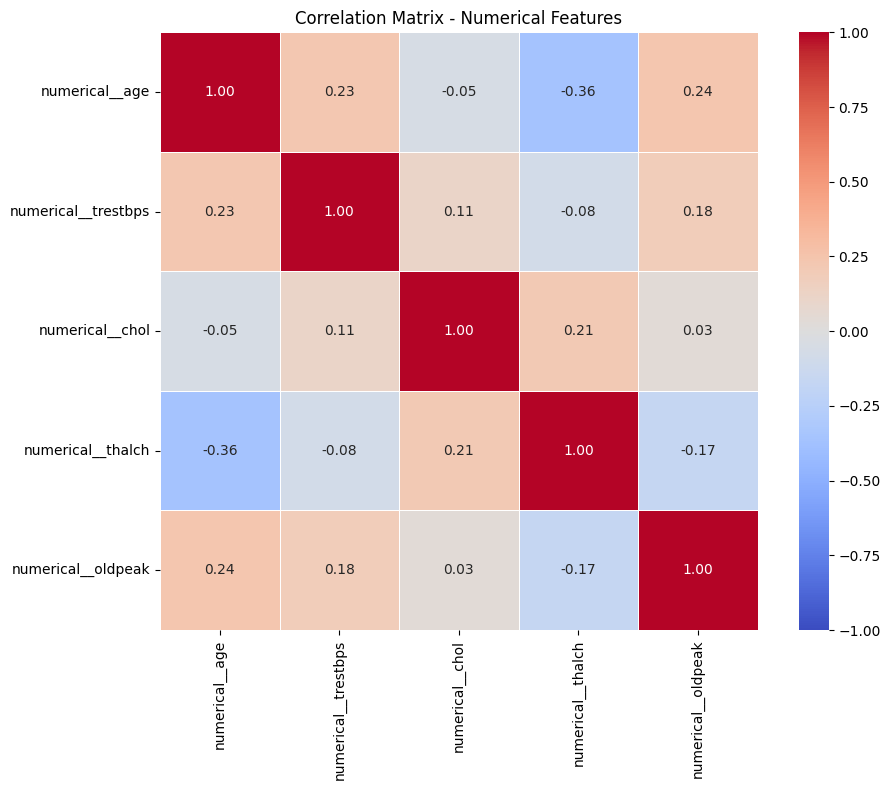

In [32]:
corr_matrix = X_train[numerical_feature].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True,       
    fmt='.2f',        
    cmap='coolwarm',  
    vmin=-1,          
    vmax=1,           
    center=0,         
    square=True,      
    linewidths=0.5    
)

plt.title('Correlation Matrix - Numerical Features')
plt.tight_layout()
plt.show()


In [ ]:
# preprocessor_scaler_encoder = ColumnTransformer(
#     transformers=[
#         ("numerical", Pipeline([
#             ('scaler', StandardScaler())
#         ]), numerical_feature),
#         ("categorical", Pipeline([
#             ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
#         ]), categorical_feature)
#     ]
# )

# preprocessor_scaler_encoder.set_output(transform="pandas")
# X_train = preprocessor_scaler_encoder.fit_transform(X_train)
# X_test = preprocessor_scaler_encoder.transform(X_test)  